# Suject dependent

In [4]:
import os
import torch
import glob
import numpy as np
import re
from collections import defaultdict
import pickle
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from tqdm import tqdm


## Set seed

In [5]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f" Random seed set to {seed}")


## pickle of past and future, each pickle is a dict of subjects

In [6]:
folder_path = "/workspaces/AH-PC/workspaces/AH-PC/src/data/EEG_DE_features"
npz_files = sorted(glob.glob(f"{folder_path}/*.npz"))

all_subjects_data = []
for npz_path in npz_files:
    with np.load(npz_path, allow_pickle=True) as npz:

        raw_data = pickle.loads(npz['data'].tobytes())
        raw_labels = pickle.loads(npz['label'].tobytes())
        all_subjects_data.append((raw_data, raw_labels))


output_dir = "/workspaces/AH-PC/workspaces/AH-PC/src/data/DE"
os.makedirs(output_dir, exist_ok=True)

past_by_subject = defaultdict(list)
future_by_subject = defaultdict(list)
past_labels_by_subject = defaultdict(list)
future_labels_by_subject = defaultdict(list)

for npz_path in npz_files:
    subject_id = int(os.path.basename(npz_path).split('_')[0])
    print(f"Processing subject {subject_id} ...")

    with np.load(npz_path, allow_pickle=True) as npz:
        raw_data = pickle.loads(npz['data'].tobytes())
        raw_labels = pickle.loads(npz['label'].tobytes())

        for trial_id, segments_flat in raw_data.items():
            segments_reshaped = segments_flat.reshape(-1, 62, 5)
            labels = raw_labels[trial_id]

            for i in range(len(segments_reshaped) - 1):
                past_by_subject[subject_id].append(segments_reshaped[i])
                future_by_subject[subject_id].append(segments_reshaped[i+1])
                past_labels_by_subject[subject_id].append(labels[i])
                future_labels_by_subject[subject_id].append(labels[i+1])

print(" Data processed for all subjects.")

# Save to disk
import pickle

for name, obj in [
    ("past_by_subject_DE.pkl", past_by_subject),
    ("future_by_subject_DE.pkl", future_by_subject),
    ("past_labels_by_subject_DE.pkl", past_labels_by_subject),
    ("future_labels_by_subject_DE.pkl", future_labels_by_subject)
]:
    with open(os.path.join(output_dir, name), "wb") as f:
        pickle.dump(dict(obj), f)

print(f" Saved all files in: {output_dir}")


 Data processed for all subjects.
 Saved all files in: /workspaces/AH-PC/workspaces/AH-PC/src/data/DE


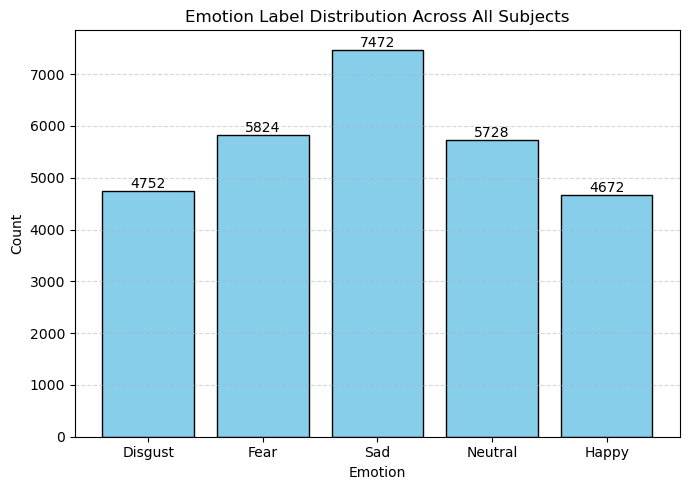

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load past labels
with open("/workspaces/AH-PC/src/data/DE/past_labels_by_subject_DE.pkl", "rb") as f:
    past_labels_by_subject = pickle.load(f)

# Optional: check structure
# print(type(past_labels_by_subject), list(past_labels_by_subject.keys()))

# Flatten all labels across subjects
all_labels = []

for subject_id, label_list in past_labels_by_subject.items():
    for label in label_list:
        if isinstance(label, (list, np.ndarray)):
            all_labels.append(int(label[0]))
        else:
            all_labels.append(int(label))

# Convert to numpy array
labels = np.array(all_labels)

# Emotion label mapping
label_dict = {0: 'Disgust', 1: 'Fear', 2: 'Sad', 3: 'Neutral', 4: 'Happy'}
label_names = [label_dict[i] for i in range(5)]

# Count frequencies
counts = [np.sum(labels == i) for i in range(5)]

# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(label_names, counts, color='skyblue', edgecolor='black')
plt.title("Emotion Label Distribution Across All Subjects")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add values above bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Fold per trial (default 3-fold on 15 trials)

In [16]:
folds_by_subject = defaultdict(list)

for subject_id in past_by_subject.keys():
    label_seq = past_labels_by_subject[subject_id]
    segs_per_trial = len(label_seq) // 15
    trial_to_indices = defaultdict(list)

    for trial_idx in range(15):
        start = trial_idx * segs_per_trial
        end = (trial_idx + 1) * segs_per_trial
        trial_to_indices[trial_idx] = list(range(start, end))

    fold_trials = [
        list(range(0, 5)),
        list(range(5, 10)),
        list(range(10, 15)),
    ]

    for fold_idx, test_trials in enumerate(fold_trials):
        train_trials = [t for t in range(15) if t not in test_trials]

        train_indices = [i for t in train_trials for i in trial_to_indices[t]]
        test_indices = [i for t in test_trials for i in trial_to_indices[t]]

        folds_by_subject[subject_id].append({
            'fold': fold_idx + 1,
            'train_indices': train_indices,
            'test_indices': test_indices
        })

print(" Trial-based 3-fold splits created for each subject.")

with open(os.path.join(output_dir, "folds_by_subject_trial_DE.pkl"), "wb") as f:
    pickle.dump(dict(folds_by_subject), f)

print(f" Saved folds_by_subject_trial_DE.pkl in: {output_dir}")


 Trial-based 3-fold splits created for each subject.
 Saved folds_by_subject_trial_DE.pkl in: /home/rml/Niki/SEED V/DE


In [ ]:
import os
import pickle
from collections import defaultdict
import numpy as np

# Load data and folds
with open("/workspaces/AH-PC/src/data/DE/past_by_subject_DE.pkl", "rb") as f:
    past_by_subject = pickle.load(f)
with open("/workspaces/AH-PC/src/data/DE/past_labels_by_subject_DE.pkl", "rb") as f:
    labels_by_subject = pickle.load(f)
with open("/workspaces/AH-PC/src/data/DE/folds_by_subject_trial_DE.pkl", "rb") as f:
    folds_by_subject = pickle.load(f)

# Save directory
save_dir = "/workspaces/AH-PC/src/data/DE/train_val_split_by_fold"
os.makedirs(save_dir, exist_ok=True)

# Loop through each subject and fold
for subject_id in folds_by_subject:
    past = np.array(past_by_subject[subject_id])     # shape: (N, 62, 5)
    labels = np.array(labels_by_subject[subject_id]) # shape: (N,)

    for fold_info in folds_by_subject[subject_id]:
        fold_id = fold_info['fold']
        train_idx = fold_info['train_indices']
        val_idx = fold_info['test_indices']

        X_train, y_train = past[train_idx], labels[train_idx]
        X_val, y_val = past[val_idx], labels[val_idx]

        with open(os.path.join(save_dir, f"train_subject{subject_id}_fold{fold_id}.pkl"), "wb") as f:
            pickle.dump((X_train, y_train), f)
        with open(os.path.join(save_dir, f"val_subject{subject_id}_fold{fold_id}.pkl"), "wb") as f:
            pickle.dump((X_val, y_val), f)

print(f" All per-subject fold files saved to: {save_dir}")


 All per-subject fold files saved to: /home/rml/Niki/SEED V/DE/train_val_split_by_fold


## Fold per session (session-level split if desired)

In [ ]:
folds_by_subject_session = defaultdict(list)

for subject_id in past_by_subject.keys():
    label_seq = past_labels_by_subject[subject_id]
    segs_per_trial = len(label_seq) // 15
    segs_per_session = segs_per_trial * 5
    session_to_indices = defaultdict(list)

    for session_idx in range(3):
        start = session_idx * segs_per_session
        end = (session_idx + 1) * segs_per_session
        session_to_indices[session_idx] = list(range(start, end))

    for fold_idx, test_session in enumerate(range(3)):
        train_sessions = [s for s in range(3) if s != test_session]

        train_indices = [i for s in train_sessions for i in session_to_indices[s]]
        test_indices = session_to_indices[test_session]

        folds_by_subject_session[subject_id].append({
            'fold': fold_idx + 1,
            'train_indices': train_indices,
            'test_indices': test_indices
        })

print(" Session-based 3-fold splits created for each subject.")

with open(os.path.join(output_dir, "folds_by_subject_session_DE.pkl"), "wb") as f:
    pickle.dump(dict(folds_by_subject_session), f)

print(f" Saved folds_by_subject_session_DE.pkl in: {output_dir}")


## Load subjects as normal

In [ ]:
import pickle
import torch
from torch.utils.data import Dataset, DataLoader

with open("/home/rml/Niki/DE/past_by_subject_DE.pkl", "rb") as f:
    past_by_subject = pickle.load(f)

with open("/home/rml/Niki/DE/future_by_subject_DE.pkl", "rb") as f:
    future_by_subject = pickle.load(f)

class DEPredictiveCodingDataset(Dataset):
    def __init__(self, past_dict, future_dict):
        self.samples = []
        for subj_id in past_dict:
            for past_seg, future_seg in zip(past_dict[subj_id], future_dict[subj_id]):
                self.samples.append((past_seg, future_seg))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x_past, x_future = self.samples[idx]
        x_past = torch.tensor(x_past, dtype=torch.float32).unsqueeze(0)   # (1, 62, 5)
        x_future = torch.tensor(x_future, dtype=torch.float32).unsqueeze(0)
        return x_past, x_future

dataset = DEPredictiveCodingDataset(past_by_subject, future_by_subject)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)


## Load subject as per trial fold

In [ ]:
#Load data & folds

with open("/workspaces/AH-PC/src/data/DE/past_by_subject_DE.pkl", "rb") as f:
    past_by_subject = pickle.load(f)

with open("/workspaces/AH-PC/src/data/DE/future_by_subject_DE.pkl", "rb") as f:
    future_by_subject = pickle.load(f)

with open("/workspaces/AH-PC/src/data/DE/folds_by_subject_trial_DE.pkl", "rb") as f:
    folds_by_subject = pickle.load(f)

print(" Data and trial-based folds loaded.")


 Data and trial-based folds loaded.


In [22]:
#Dataset class

import torch
from torch.utils.data import Dataset

class DEPredictiveCodingDataset(Dataset):
    def __init__(self, past_subject, future_subject, indices):
        self.samples = [
            (past_subject[i], future_subject[i])
            for i in indices
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x_past, x_future = self.samples[idx]
        x_past = torch.tensor(x_past, dtype=torch.float32).unsqueeze(0)   # (1, 62, 5)
        x_future = torch.tensor(x_future, dtype=torch.float32).unsqueeze(0)
        return x_past, x_future


## Predictive coding structure

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BandAttention(nn.Module):
    def __init__(self, num_bands):
        super().__init__()
        self.fc1 = nn.Linear(num_bands * 2, num_bands // 2)
        self.fc2 = nn.Linear(num_bands // 2, num_bands)

    def forward(self, x):  # x: (B, C, B)
        avg_pool = x.mean(dim=1)
        max_pool = x.max(dim=1).values
        context = torch.cat([avg_pool, max_pool], dim=-1)
        weights = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(1)


class ChannelAttention(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.fc1 = nn.Linear(num_channels * 2, num_channels // 2)
        self.fc2 = nn.Linear(num_channels // 2, num_channels)

    def forward(self, x):  # x: (B, C, B)
        avg_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        context = torch.cat([avg_pool, max_pool], dim=-1)
        weights = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(2)


In [24]:
class CNNPredictiveCodingDE_Attn(nn.Module):
    def __init__(self):
        super(CNNPredictiveCodingDE_Attn, self).__init__()

        self.band_attn = BandAttention(num_bands=5)
        self.channel_attn = ChannelAttention(num_channels=62)

        # Encoder: input shape (B, 1, 62, 5)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),    # (B, 16, 62, 5)
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2, 1)),                          # (B, 16, 31, 5)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),   # (B, 32, 31, 5)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 1))                           # (B, 32, 15, 5)
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # (B, 64, 15, 5)
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=(2,1), stride=(2,1)),  # (B, 32, 30, 5)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=(2,1), stride=(2,1)),  # (B, 16, 60, 5)
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),                   # (B, 1, 60, 5)
            nn.Upsample(size=(62,5), mode='bilinear', align_corners=False) # final resize
        )

    def forward(self, x):  # x: (B, 62, 5)
        x = self.band_attn(x)
        x = self.channel_attn(x)
        x = x.unsqueeze(1)             # (B, 1, 62, 5)
        x = self.encoder(x)            # (B, 32, 15, 5)
        x = self.bottleneck(x)         # (B, 64, 15, 5)
        x = self.decoder(x)            # (B, 1, 62, 5)
        return x.squeeze(1)            # (B, 62, 5)

    def get_embedding(self, x):
        x = self.band_attn(x)
        x = self.channel_attn(x)
        x = x.unsqueeze(1)
        return self.bottleneck(self.encoder(x))  # (B, 64, 15, 5)


In [ ]:
from torch.utils.data import DataLoader

def get_subject_fold_data(subject_id, fold_idx):
    with open("/workspaces/AH-PC/src/data/DE/past_by_subject_DE.pkl", "rb") as f:
        past_by_subject = pickle.load(f)
    with open("/workspaces/AH-PC/src/data/DE/future_by_subject_DE.pkl", "rb") as f:
        future_by_subject = pickle.load(f)
    with open("/workspaces/AH-PC/src/data/DE/folds_by_subject_trial_DE.pkl", "rb") as f:
        folds_by_subject = pickle.load(f)

    fold = folds_by_subject[subject_id][fold_idx]
    train_indices = fold['train_indices']
    test_indices = fold['test_indices']

    X_train = np.stack([past_by_subject[subject_id][i] for i in train_indices])
    Y_train = np.stack([future_by_subject[subject_id][i] for i in train_indices])
    X_val = np.stack([past_by_subject[subject_id][i] for i in test_indices])
    Y_val = np.stack([future_by_subject[subject_id][i] for i in test_indices])

    return X_train, Y_train, X_val, Y_val



In [35]:
  # or define inline
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import defaultdict
import numpy as np
import pickle
import gc
from tqdm import tqdm

# -------------------- Hyperparameters --------------------
epochs = 30
batch_size = 256
learning_rate = 5e-4
weight_decay = 1e-5
max_grad_norm = 5.0
save_dir = "/home/rml/Niki/SEED V/models_attn_DE"  #  CUSTOM DIRECTORY

# -------------------- Logs and Device --------------------
train_loss_log = defaultdict(list)
val_loss_log = defaultdict(list)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------- Training Loop --------------------
subjects = sorted(past_by_subject.keys())

for subject_id in subjects:
    print(f"\nSubject {subject_id}")
    for fold_idx in range(3):
        print(f" Fold {fold_idx+1}/3")

        X_train, Y_train, X_val, Y_val = get_subject_fold_data(subject_id, fold_idx)

        train_loader = DataLoader(
            TensorDataset(
                torch.tensor(X_train).float(),  # (B, 62, 5)
                torch.tensor(Y_train).float()
            ),
            batch_size=batch_size,
            shuffle=True
        )

        val_loader = DataLoader(
            TensorDataset(
                torch.tensor(X_val).float(),
                torch.tensor(Y_val).float()
            ),
            batch_size=batch_size,
            shuffle=False
        )

        model = CNNPredictiveCodingDE_Attn().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        loss_fn = nn.MSELoss()
        best_val_loss = float('inf')

        for epoch in range(1, epochs + 1):
            model.train()
            train_loss = 0.0
            for batch_idx, (xb, yb) in enumerate(tqdm(train_loader, desc=f" Epoch {epoch}/{epochs} [Train]", leave=False)):
                xb, yb = xb.to(device), yb.to(device)

                optimizer.zero_grad()
                pred = model(xb)

                if torch.isnan(pred).any() or torch.isinf(pred).any():
                    print(f" NaN/Inf in prediction at Subject {subject_id}, Fold {fold_idx+1}, Epoch {epoch}, Batch {batch_idx}")
                    continue

                loss = loss_fn(pred, yb)
                if torch.isnan(loss) or torch.isinf(loss):
                    print(f" NaN/Inf in loss at Subject {subject_id}, Fold {fold_idx+1}, Epoch {epoch}, Batch {batch_idx}")
                    continue

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
                optimizer.step()
                train_loss += loss.item()

            avg_train_loss = train_loss / len(train_loader)
            train_loss_log[(subject_id, fold_idx)].append(avg_train_loss)

            # Validation
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in tqdm(val_loader, desc=f" Epoch {epoch}/{epochs} [Val]", leave=False):
                    xb, yb = xb.to(device), yb.to(device)
                    pred = model(xb)
                    val_loss += loss_fn(pred, yb).item()

            avg_val_loss = val_loss / len(val_loader)
            val_loss_log[(subject_id, fold_idx)].append(avg_val_loss)

            print(f"  Epoch {epoch:02d} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f}")

            # Save best model
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                os.makedirs(save_dir, exist_ok=True)
                model_path = os.path.join(save_dir, f"subject{subject_id}_fold{fold_idx+1}_best.pt")
                torch.save(model.state_dict(), model_path)
                print(f"  Saved best model to {model_path}")

            # Memory cleanup
            if epoch % 5 == 0:
                print(f" Epoch {epoch} | GPU Mem: {torch.cuda.memory_allocated() / 1e6:.2f} MB")
                torch.cuda.empty_cache()
                gc.collect()

        # Cleanup
        del model, train_loader, val_loader
        torch.cuda.empty_cache()
        gc.collect()

print("\n Training complete for all subjects and folds.")


Using device: cuda

Subject 1
 Fold 1/3


  Epoch 01 | Train: 36.947316 | Val: 37.769591
  Saved best model to /home/rml/Niki/SEED V/models_attn_DE/subject1_fold1_best.pt


  Epoch 02 | Train: 35.699014 | Val: 37.064060
  Saved best model to /home/rml/Niki/SEED V/models_attn_DE/subject1_fold1_best.pt


  Epoch 03 | Train: 34.310889 | Val: 35.778478
  Saved best model to /home/rml/Niki/SEED V/models_attn_DE/subject1_fold1_best.pt


  Epoch 04 | Train: 32.673861 | Val: 33.610982
  Saved best model to /home/rml/Niki/SEED V/models_attn_DE/subject1_fold1_best.pt


...

  Epoch 26 | Train: 0.537109 | Val: 0.918160
  Saved best model to /home/rml/Niki/SEED V/models_attn_DE/subject16_fold3_best.pt


  Epoch 27 | Train: 0.515221 | Val: 0.917320
  Saved best model to /home/rml/Niki/SEED V/models_attn_DE/subject16_fold3_best.pt


  Epoch 28 | Train: 0.498084 | Val: 0.849145
  Saved best model to /home/rml/Niki/SEED V/models_attn_DE/subject16_fold3_best.pt


  Epoch 29 | Train: 0.480399 | Val: 0.831863
  Saved best model to /home/rml/Niki/SEED V/models_attn_DE/subject16_fold3_best.pt


  Epoch 30 | Train: 0.465462 | Val: 0.835698
 Epoch 30 | GPU Mem: 19.21 MB

 Training complete for all subjects and folds.


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

model = CNNPredictiveCodingDE_Attn().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


 Using device: cuda


CNNPredictiveCodingDE_Attn(
  (band_attn): BandAttention(
    (fc1): Linear(in_features=10, out_features=2, bias=True)
    (fc2): Linear(in_features=2, out_features=5, bias=True)
  )
  (channel_attn): ChannelAttention(
    (fc1): Linear(in_features=124, out_features=31, bias=True)
    (fc2): Linear(in_features=31, out_features=62, bias=True)
  )
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck): Sequential(
    (0): Conv2d(32, 64, k

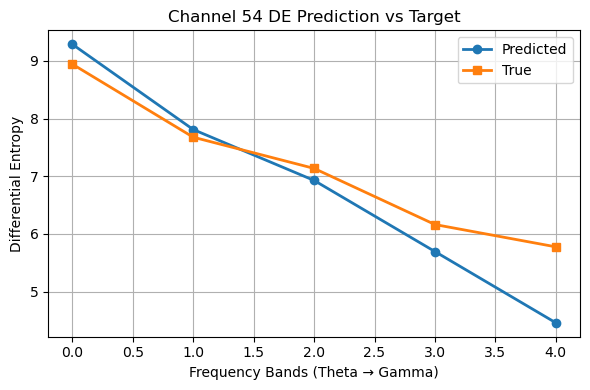

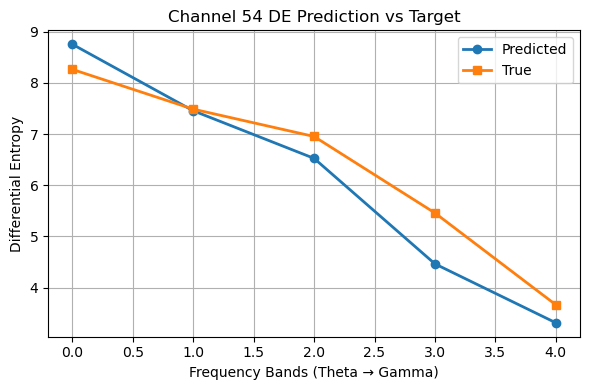

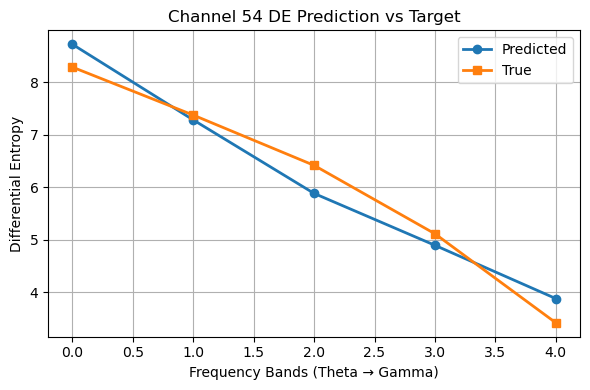

In [39]:
import matplotlib.pyplot as plt
import torch

n_samples = 3
indices = torch.randint(0, len(X_val), (n_samples,))

channel_id = 54  # EEG channel to plot

for idx in indices:
    # Convert sample to tensor and move to device
    x = torch.tensor(X_val[idx]).unsqueeze(0).float().to(device)  # (1, 62, 5)
    y_true = Y_val[idx]  # already numpy, shape: (62, 5)

    with torch.no_grad():
        pred = model(x).cpu().squeeze(0).numpy()  # (62, 5)

    # Plot for one channel
    plt.figure(figsize=(6, 4))
    plt.plot(pred[channel_id], marker='o', label="Predicted", linewidth=2)
    plt.plot(y_true[channel_id], marker='s', label="True", linewidth=2)
    plt.title(f"Channel {channel_id} DE Prediction vs Target")
    plt.xlabel("Frequency Bands (Theta → Gamma)")
    plt.ylabel("Differential Entropy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


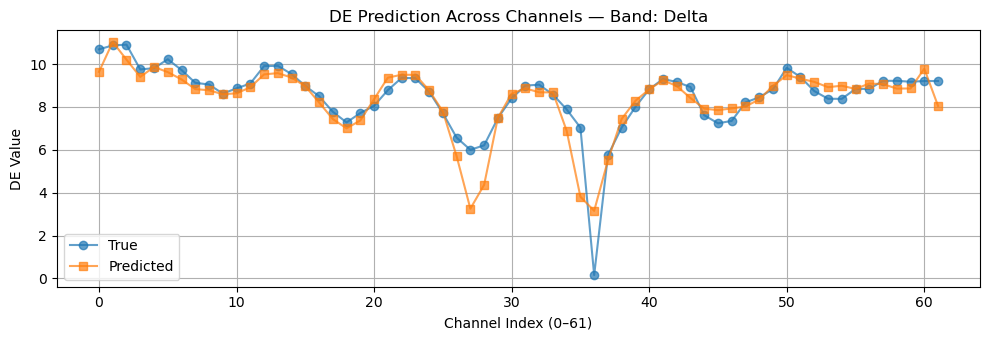

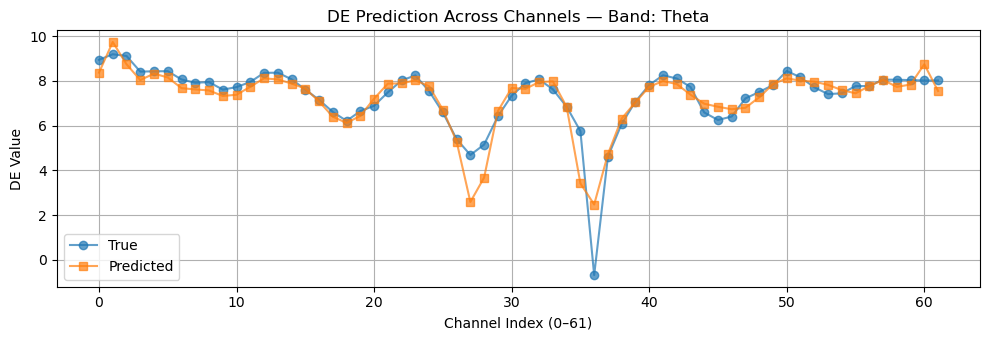

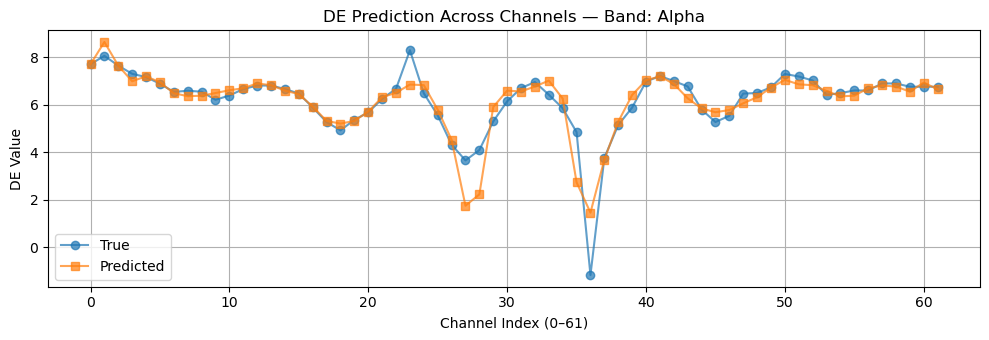

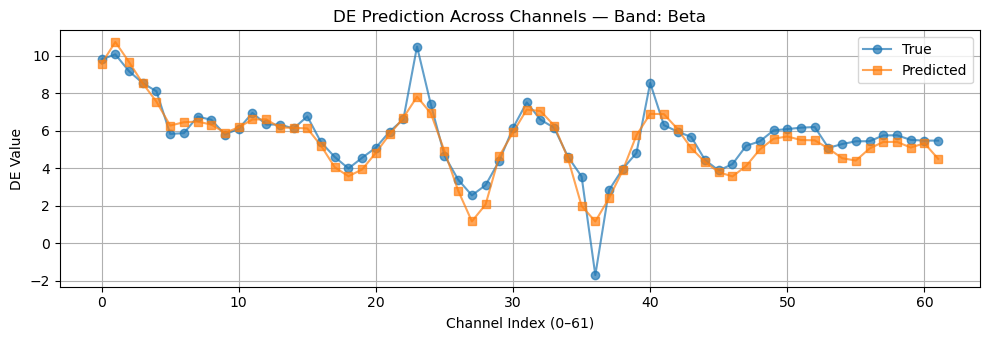

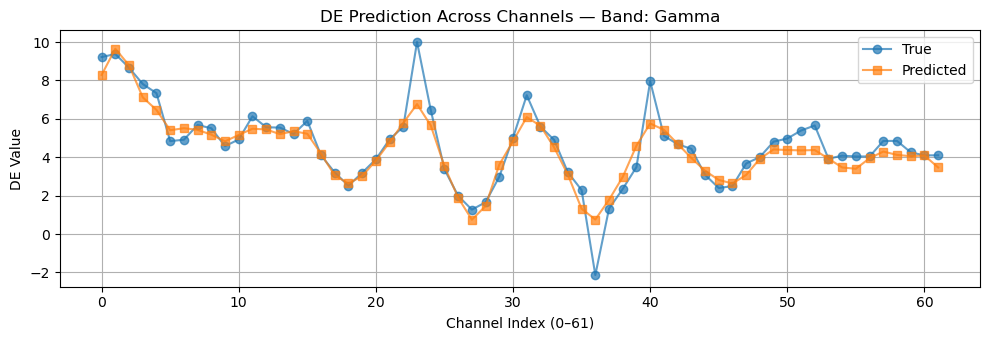

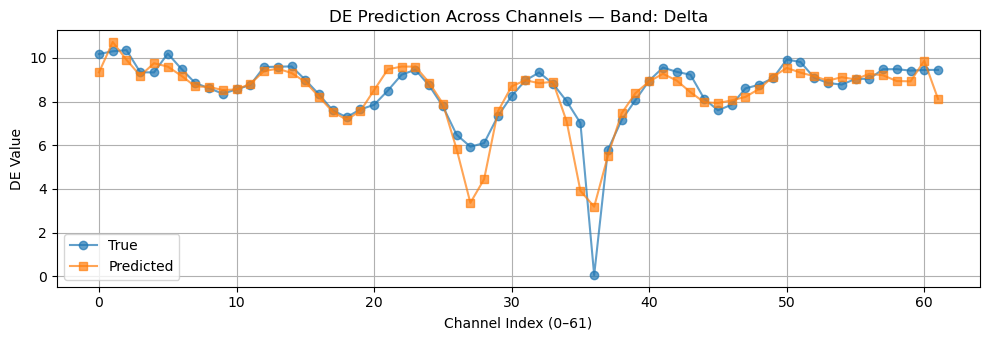

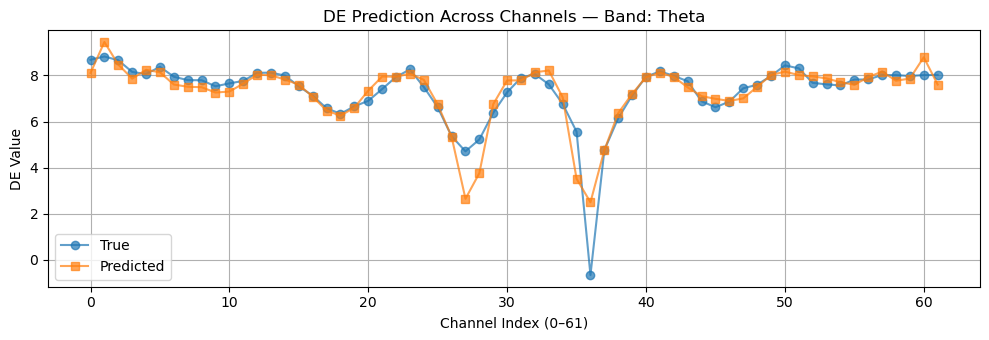

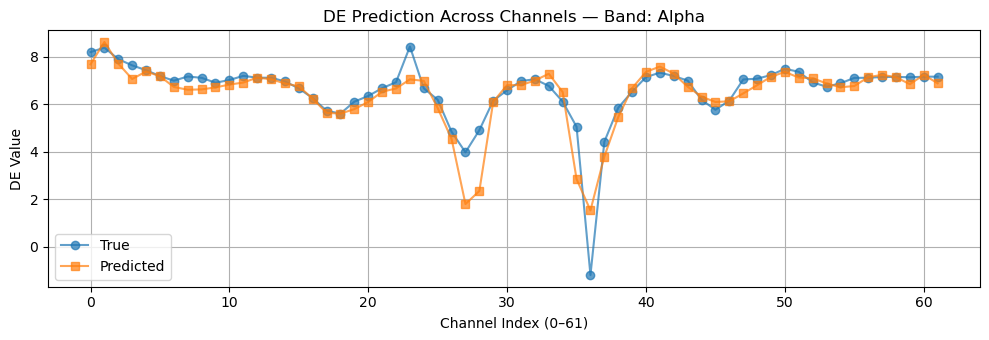

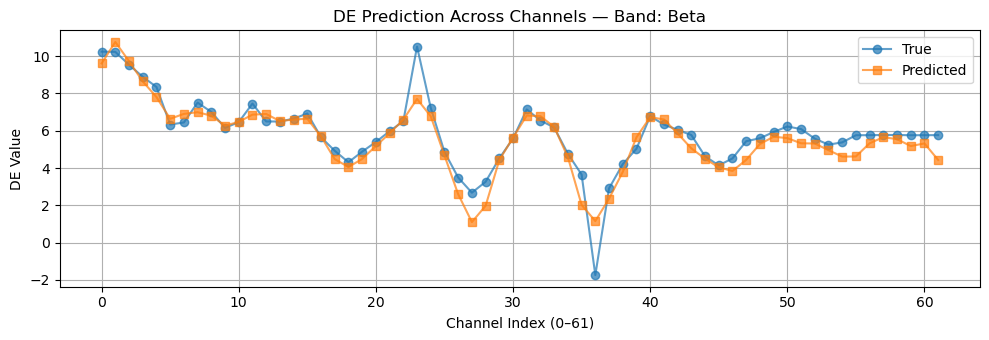

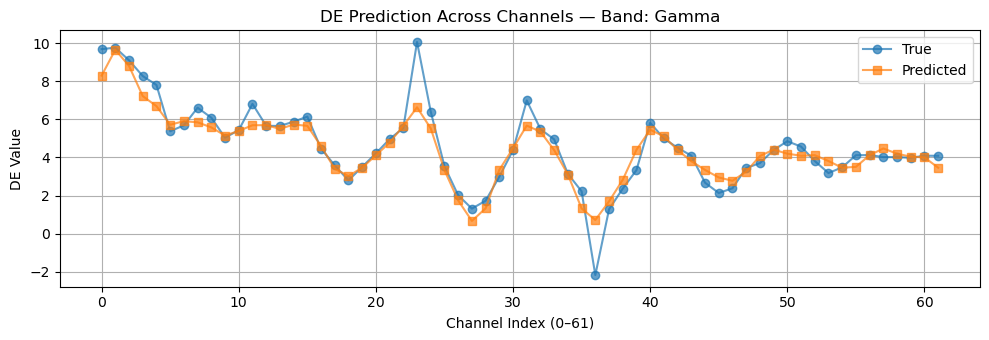

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Select N random samples from validation
n_samples = 2
indices = torch.randint(0, len(X_val), (n_samples,))
band_names = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]

for idx in indices:
    x = torch.tensor(X_val[idx]).unsqueeze(0).float().to(device)  # (1, 62, 5)
    y_true = Y_val[idx]  # (62, 5)

    with torch.no_grad():
        y_pred = model(x).cpu().squeeze(0).numpy()  # (62, 5)

    # Plot band-wise comparison
    for band_idx in range(5):
        plt.figure(figsize=(10, 3.5))
        plt.plot(y_true[:, band_idx], marker='o', label="True", alpha=0.7)
        plt.plot(y_pred[:, band_idx], marker='s', label="Predicted", alpha=0.7)
        plt.title(f"DE Prediction Across Channels — Band: {band_names[band_idx]}")
        plt.xlabel("Channel Index (0–61)")
        plt.ylabel("DE Value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


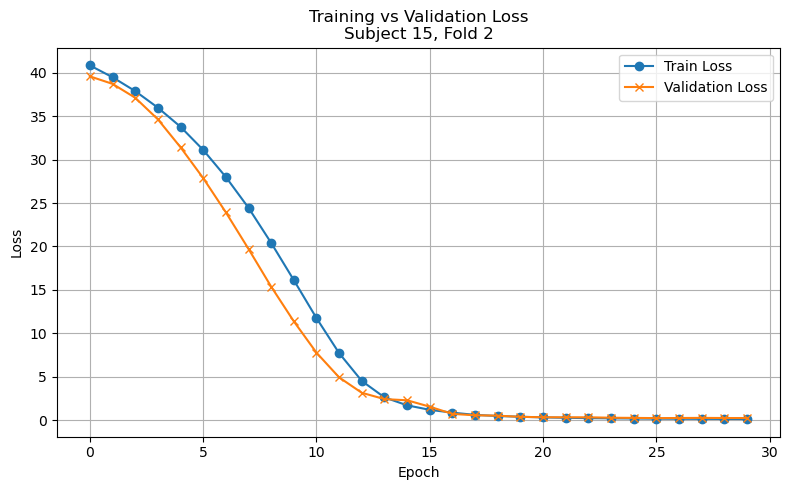

In [41]:
subject_id = 15  # or any subject in your dataset
fold_idx = 1    # 0-based index for fold 1/3

train_losses = train_loss_log[(subject_id, fold_idx)]
val_losses = val_loss_log[(subject_id, fold_idx)]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training vs Validation Loss\nSubject {subject_id}, Fold {fold_idx+1}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pickle
import os
import re
from torch.utils.data import DataLoader, TensorDataset
from collections import OrderedDict

# -------------------- Attention Modules --------------------
class BandAttention(nn.Module):
    def __init__(self, num_bands):
        super().__init__()
        self.fc1 = nn.Linear(num_bands * 2, num_bands // 2)
        self.fc2 = nn.Linear(num_bands // 2, num_bands)

    def forward(self, x):
        avg_pool = x.mean(dim=1)
        max_pool = x.max(dim=1).values
        context = torch.cat([avg_pool, max_pool], dim=-1)
        weights = torch.sigmoid(self.fc2(torch.relu(self.fc1(context))))
        return x * weights.unsqueeze(1)

class ChannelAttention(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.fc1 = nn.Linear(num_channels * 2, num_channels // 2)
        self.fc2 = nn.Linear(num_channels // 2, num_channels)

    def forward(self, x):
        avg_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        context = torch.cat([avg_pool, max_pool], dim=-1)
        weights = torch.sigmoid(self.fc2(torch.relu(self.fc1(context))))
        return x * weights.unsqueeze(2)

# -------------------- Predictive Coding Model w/ Attention --------------------
class CNNPredictiveCodingDE_Attn(nn.Module):
    def __init__(self):
        super().__init__()
        self.band_attn = BandAttention(num_bands=5)
        self.channel_attn = ChannelAttention(num_channels=62)

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2, 1)),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 1))
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

    def forward(self, x):  # For reconstruction (not used here)
        x = self.band_attn(x)
        x = self.channel_attn(x)
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.bottleneck(x)
        return x

    def get_embedding(self, x):  # (B, 62, 5)
        x = self.band_attn(x)
        x = self.channel_attn(x)
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.bottleneck(x)
        return x.flatten(start_dim=1)  # (B, 64 * 15 * 5)

# -------------------- Load Data --------------------
with open("/workspaces/AH-PC/src/data/DE/past_by_subject_DE.pkl", "rb") as f:
    X_past = pickle.load(f)
with open("/workspaces/AH-PC/src/data/DE/past_labels_by_subject_DE.pkl", "rb") as f:
    past_labels = pickle.load(f)

# -------------------- Setup --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_dir = "/home/rml/Niki/SEED V/models_attn_DE"
output_dir = "/home/rml/Niki/SEED V/embeddings_by_fold"
os.makedirs(output_dir, exist_ok=True)

checkpoints = sorted([f for f in os.listdir(model_dir) if f.endswith(".pt")])



# -------------------- Process Each Checkpoint --------------------
for ckpt in checkpoints:
    match = re.match(r"subject(\d+)_fold(\d+)_best\.pt", ckpt)
    if not match:
        continue

    subject_id = int(match.group(1))
    fold_id = int(match.group(2))
    print(f"\nProcessing Subject {subject_id} - Fold {fold_id}")

    if subject_id not in X_past:
        print(f"  Skipping: Subject {subject_id} not found in data.")
        continue

    X = torch.tensor(X_past[subject_id], dtype=torch.float32)  # (N, 62, 5)
    y = torch.tensor(past_labels[subject_id], dtype=torch.long)
    loader = DataLoader(TensorDataset(X), batch_size=64, shuffle=False)

    model = CNNPredictiveCodingDE_Attn().to(device)
    state_dict = torch.load(os.path.join(model_dir, ckpt), map_location=device)
    clean_state_dict = OrderedDict((k.replace("module.", ""), v) for k, v in state_dict.items())
    model.load_state_dict(clean_state_dict, strict=False)
    model.eval()

    base = f"{output_dir}/subject{subject_id}_fold{fold_id}"

    # ======== INSERT: save baseline (no predictive coding) inputs ========
    # Flatten the pre-encoder input once (order matches DataLoader since shuffle=False)
    x_baseline = X.view(X.shape[0], -1).numpy()     # shape: (N, 62*5)
    np.save(base + "_inputs.npy", x_baseline)       # <- baseline saved here
    # ====================================================================

    embeddings = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            out = model.get_embedding(xb)
            embeddings.append(out.cpu())

    embeddings = torch.cat(embeddings, dim=0).numpy()
    labels = y.numpy()

    np.save(base + "_embeddings.npy", embeddings)
    np.save(base + "_labels.npy", labels)
    print(f"   Saved: {base}_embeddings.npy | shape: {embeddings.shape}")
    print(f"   Saved: {base}_inputs.npy     | shape: {x_baseline.shape}")


Using device: cuda

Processing Subject 10 - Fold 1
   Saved: /home/rml/Niki/SEED V/embeddings_by_fold/subject10_fold1_embeddings.npy | shape: (1778, 4800)
   Saved: /home/rml/Niki/SEED V/embeddings_by_fold/subject10_fold1_inputs.npy     | shape: (1778, 310)

Processing Subject 10 - Fold 2
   Saved: /home/rml/Niki/SEED V/embeddings_by_fold/subject10_fold2_embeddings.npy | shape: (1778, 4800)
   Saved: /home/rml/Niki/SEED V/embeddings_by_fold/subject10_fold2_inputs.npy     | shape: (1778, 310)

Processing Subject 10 - Fold 3
   Saved: /home/rml/Niki/SEED V/embeddings_by_fold/subject10_fold3_embeddings.npy | shape: (1778, 4800)
   Saved: /home/rml/Niki/SEED V/embeddings_by_fold/subject10_fold3_inputs.npy     | shape: (1778, 310)

Processing Subject 11 - Fold 1
   Saved: /home/rml/Niki/SEED V/embeddings_by_fold/subject11_fold1_embeddings.npy | shape: (1778, 4800)
   Saved: /home/rml/Niki/SEED V/embeddings_by_fold/subject11_fold1_inputs.npy     | shape: (1778, 310)

Processing Subject 11 - 

[INFO] After-PC ALL: (85344, 4800), labels: (85344,)
[INFO] Baseline ALL: (85344, 310)


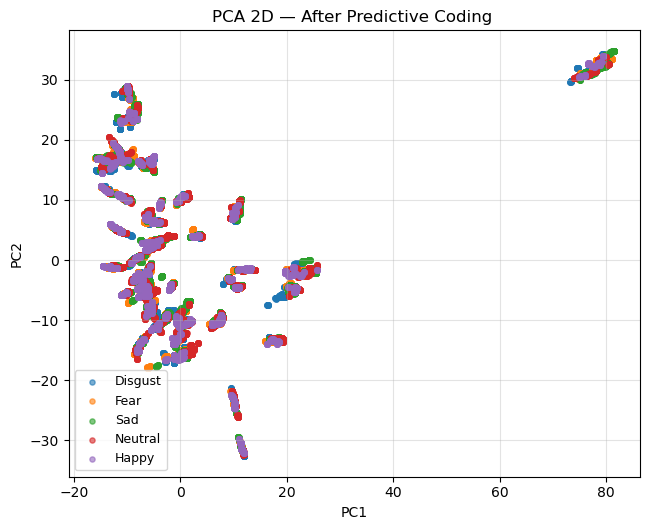

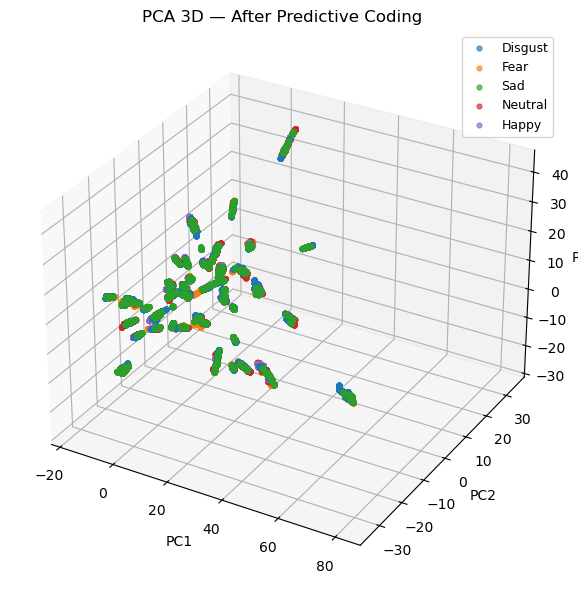

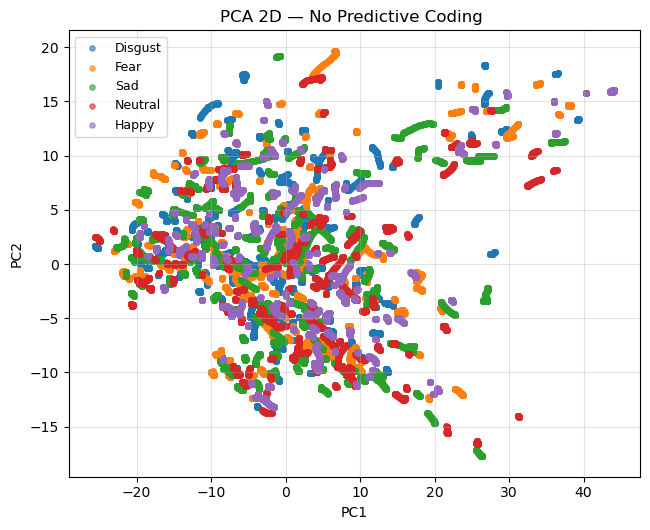

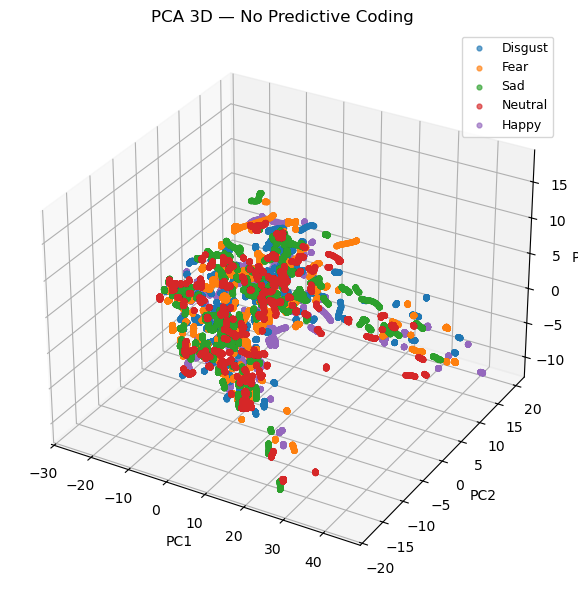

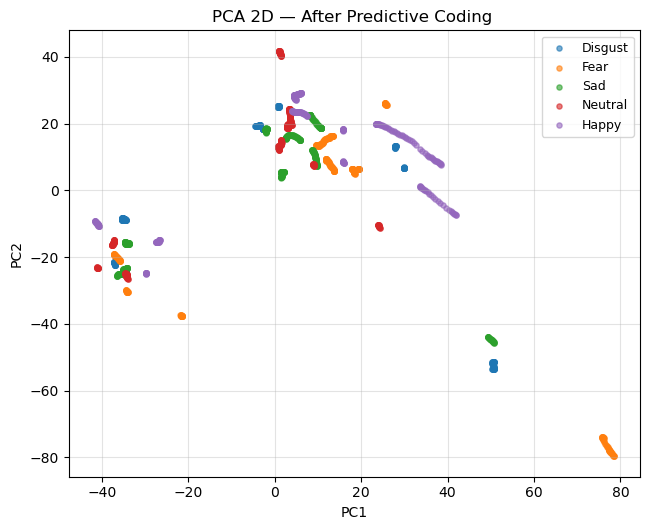

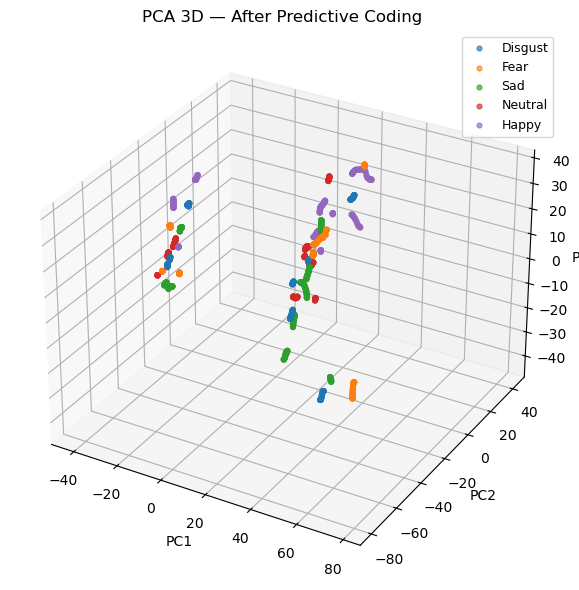

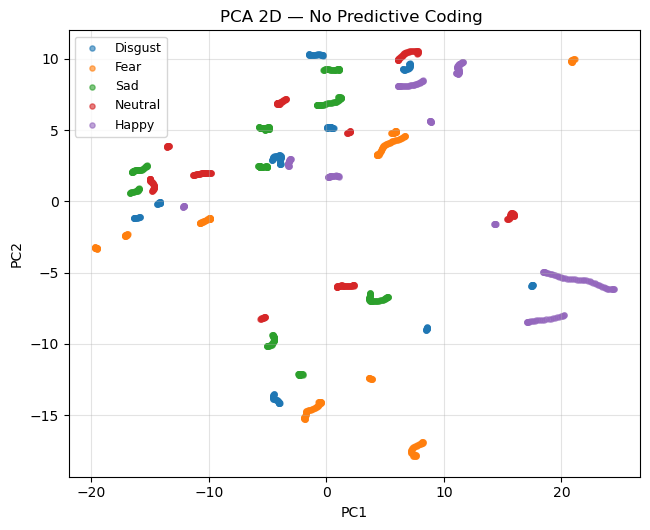

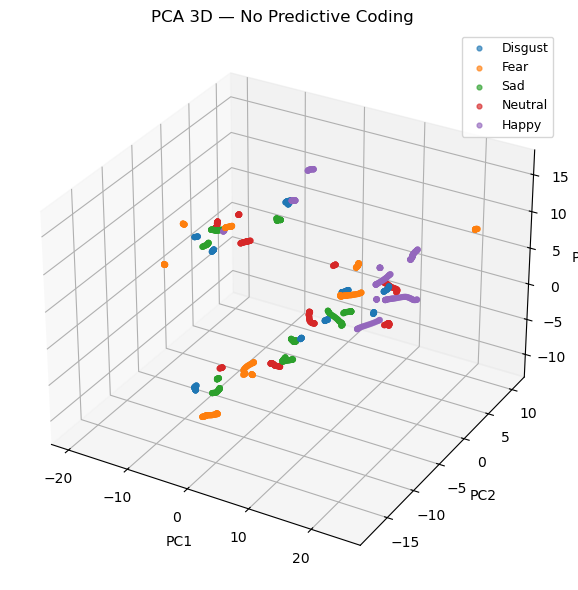

In [68]:
import os, re, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ===================== CONFIG =====================
ROOT = "/home/rml/Niki/SEED V/embeddings_by_fold"
USE_BASELINE_INPUTS = True

# choose a sample (subject, fold) to show per-fold comparison
SAMPLE_SUBJECT = 16
SAMPLE_FOLD    = 3
# class label map
label_map = {
    0: "Disgust",
    1: "Fear",
    2: "Sad",
    3: "Neutral",
    4: "Happy"
}

# ===================== HELPERS =====================
def find_pairs(root):
    root = Path(root)
    emb_files = sorted(root.rglob("*_embeddings.npy"))
    items = []
    pat = re.compile(r"subject(?P<subj>\d+)_fold(?P<fold>\d+)_embeddings\.npy$")
    for ef in emb_files:
        m = pat.search(ef.name)
        if m:
            subj, fold = int(m.group("subj")), int(m.group("fold"))
        else:
            m2 = re.search(r"subject(\d+)_fold(\d+)", ef.name)
            if not m2:
                continue
            subj, fold = int(m2.group(1)), int(m2.group(2))

        lab = ef.with_name(ef.name.replace("_embeddings.npy", "_labels.npy"))
        inp = ef.with_name(ef.name.replace("_embeddings.npy", "_inputs.npy"))
        if not lab.exists():
            continue
        items.append({
            "subject": subj,
            "fold": fold,
            "emb": ef,
            "lab": lab,
            "inp": inp if inp.exists() else None
        })
    return items

def concat_arrays(arrs):
    return np.concatenate(arrs, axis=0) if len(arrs) > 1 else arrs[0]

def plot_pca_2d(X, y, title):
    sc = StandardScaler().fit(X)
    Xs = sc.transform(X)
    Xp = PCA(n_components=2).fit_transform(Xs)

    plt.figure(figsize=(6.6, 5.4))
    for lbl in np.unique(y):
        idx = (y == lbl)
        name = label_map.get(lbl, str(lbl))
        plt.scatter(Xp[idx, 0], Xp[idx, 1], s=14, alpha=0.6, label=name)
    plt.title(title)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()

def plot_pca_3d(X, y, title):
    sc = StandardScaler().fit(X)
    Xs = sc.transform(X)
    Xp = PCA(n_components=3).fit_transform(Xs)

    fig = plt.figure(figsize=(7.2, 6.0))
    ax = fig.add_subplot(111, projection='3d')
    for lbl in np.unique(y):
        idx = (y == lbl)
        name = label_map.get(lbl, str(lbl))
        ax.scatter(Xp[idx, 0], Xp[idx, 1], Xp[idx, 2], s=12, alpha=0.65, label=name)
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

# ===================== LOAD =====================
items = find_pairs(ROOT)
assert len(items) > 0, f"No embedding files found under {ROOT}"

emb_all, lab_all = [], []
inp_all = []

# also keep track of one sample subject/fold
sample_emb = sample_lab = sample_inp = None

for it in items:
    X_emb = np.load(it["emb"])
    y = np.load(it["lab"])
    if X_emb.shape[0] != y.shape[0]:
        print(f"[WARN] skip mismatch: {it['emb'].name}")
        continue

    emb_all.append(X_emb)
    lab_all.append(y)

    if USE_BASELINE_INPUTS and it["inp"] is not None:
        X_inp = np.load(it["inp"])
        if X_inp.shape[0] == y.shape[0]:
            inp_all.append(X_inp)

    if it["subject"] == SAMPLE_SUBJECT and it["fold"] == SAMPLE_FOLD:
        sample_emb = X_emb
        sample_lab = y
        if USE_BASELINE_INPUTS and it["inp"] is not None:
            sample_inp = np.load(it["inp"])

X_after_all = concat_arrays(emb_all)
y_all = concat_arrays(lab_all)
print(f"[INFO] After-PC ALL: {X_after_all.shape}, labels: {y_all.shape}")

X_before_all = None
if USE_BASELINE_INPUTS and len(inp_all) > 0:
    X_before_all = concat_arrays(inp_all)
    print(f"[INFO] Baseline ALL: {X_before_all.shape}")

# ===================== PCA: ALL (After-PC vs Baseline) =====================
plot_pca_2d(X_after_all, y_all, "PCA 2D — After Predictive Coding ")
plot_pca_3d(X_after_all, y_all, "PCA 3D — After Predictive Coding ")

if X_before_all is not None:
    plot_pca_2d(X_before_all, y_all, "PCA 2D — No Predictive Coding ")
    plot_pca_3d(X_before_all, y_all, "PCA 3D — No Predictive Coding ")

# ===================== PCA: SAMPLE SUBJECT/FOLD =====================
if (sample_emb is not None) and (sample_lab is not None):
    plot_pca_2d(sample_emb, sample_lab,
                f"PCA 2D — After Predictive Coding ")
    plot_pca_3d(sample_emb, sample_lab,
                f"PCA 3D — After Predictive Coding ")

    if USE_BASELINE_INPUTS and (sample_inp is not None):
        plot_pca_2d(sample_inp, sample_lab,
                    f"PCA 2D — No Predictive Coding ")
        plot_pca_3d(sample_inp, sample_lab,
                    f"PCA 3D — No Predictive Coding ")


Loaded embeddings: (1778, 4800), labels: (1778,)


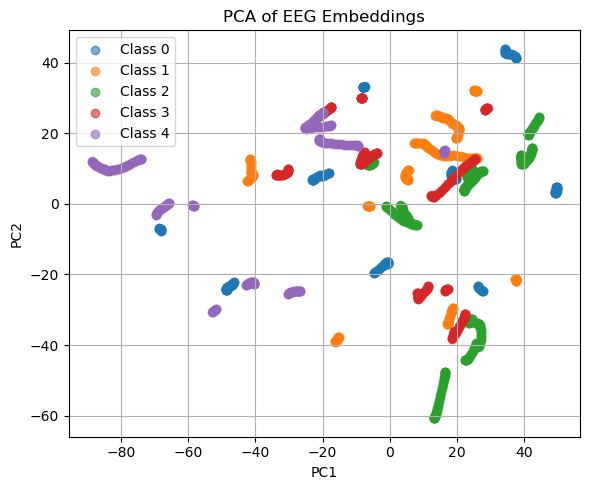

/home/rml/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


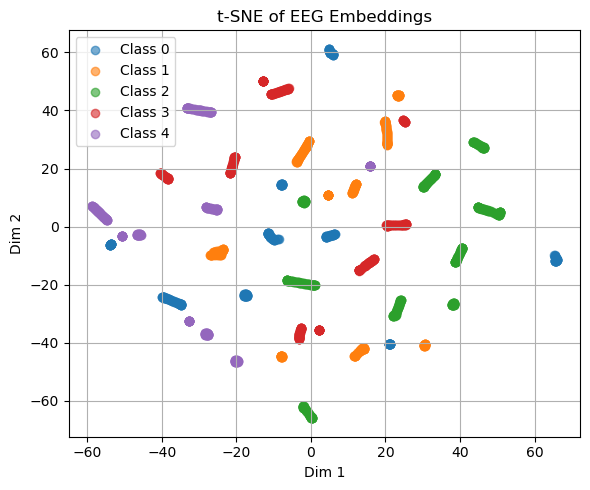

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# -------------------- Load Embeddings --------------------
# Replace with your actual file path:
base = "/home/rml/Niki/SEED V/embeddings_by_fold/subject9_fold2"
X = np.load(base + "_embeddings.npy")  # shape: (N, D)
y = np.load(base + "_labels.npy")      # shape: (N,)

print(f"Loaded embeddings: {X.shape}, labels: {y.shape}")

# -------------------- Standardize --------------------
X_std = StandardScaler().fit_transform(X)

# -------------------- PCA --------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(6, 5))
for label in np.unique(y):
    idx = y == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Class {label}", alpha=0.6)
plt.title("PCA of EEG Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------- t-SNE --------------------
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_std)

plt.figure(figsize=(6, 5))
for label in np.unique(y):
    idx = y == label
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=f"Class {label}", alpha=0.6)
plt.title("t-SNE of EEG Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


2:
fine tuning cnn

In [23]:
import numpy as np
labels = np.load("embeddings_by_fold/fold1_labels.npy")
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))


{0.0: 1587, 1.0: 1929, 2.0: 2506, 3.0: 1921, 4.0: 1540}


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pickle
import os
import re
from sklearn.model_selection import train_test_split

# -------------------- Attention Modules --------------------
class BandAttention(nn.Module):
    def __init__(self, num_bands):
        super().__init__()
        self.fc1 = nn.Linear(num_bands * 2, num_bands // 2)
        self.fc2 = nn.Linear(num_bands // 2, num_bands)

    def forward(self, x):
        avg_pool = x.mean(dim=1)
        max_pool = x.max(dim=1).values
        context = torch.cat([avg_pool, max_pool], dim=-1)
        weights = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(1)

class ChannelAttention(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.fc1 = nn.Linear(num_channels * 2, num_channels // 2)
        self.fc2 = nn.Linear(num_channels // 2, num_channels)

    def forward(self, x):
        avg_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        context = torch.cat([avg_pool, max_pool], dim=-1)
        weights = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(2)

# -------------------- Base Model --------------------
class CNNPredictiveCodingDE_Attn(nn.Module):
    def __init__(self):
        super().__init__()
        self.band_attn = BandAttention(num_bands=5)
        self.channel_attn = ChannelAttention(num_channels=62)

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2, 1)),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 1))
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.band_attn(x)
        x = self.channel_attn(x)
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.bottleneck(x)
        return x

# -------------------- Classifier --------------------
class EEGEmotionClassifier(nn.Module):
    def __init__(self, base_model, n_classes=5):
        super().__init__()
        self.base_model = base_model  # instead of separating encoder/bottleneck

        dummy = torch.zeros(1, 62, 5).to(next(self.base_model.parameters()).device)
        with torch.no_grad():
            latent = self.base_model(dummy)
            flat_dim = latent.flatten(1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.base_model(x)  # includes attention + unsqueeze(1) inside
        return self.classifier(x)



# -------------------- Load Data --------------------
with open("/workspaces/AH-PC/src/data/DE/past_by_subject_DE.pkl", "rb") as f:
    X_past = pickle.load(f)
with open("/workspaces/AH-PC/src/data/DE/past_labels_by_subject_DE.pkl", "rb") as f:
    y_labels = pickle.load(f)

X = np.concatenate([X_past[sid] for sid in sorted(X_past)], axis=0)
y = np.concatenate([np.array(y_labels[sid]) for sid in sorted(y_labels)])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

# squeeze the channel dim (from [B,1,62,5] → [B,62,5])
if X_train.ndim == 4 and X_train.shape[1] == 1:
    X_train = X_train.squeeze(1)
    X_val = X_val.squeeze(1)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64)


# -------------------- Loop Over Pretrained Models --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_dir = "/home/rml/Niki/SEED V/models_attn_DE"
output_dir = "/home/rml/Niki/SEED V/fine_tuned"
os.makedirs(output_dir, exist_ok=True)

checkpoints = sorted([f for f in os.listdir(model_dir) if f.endswith(".pt")])

all_val_accuracies = []  
for ckpt in checkpoints:
    match = re.match(r"subject(\d+)_fold(\d+)_best\.pt", ckpt)
    if not match:
        continue

    subject_id = int(match.group(1))
    fold_id = int(match.group(2))
    print(f"\nFine-tuning for Subject {subject_id}, Fold {fold_id}")

    model_path = os.path.join(model_dir, ckpt)
    base_model = CNNPredictiveCodingDE_Attn().to(device)

    state_dict = torch.load(model_path, map_location=device)
    base_model.load_state_dict(state_dict, strict=False)

    model = EEGEmotionClassifier(base_model, n_classes=5).to(device)

    # Freeze early encoder layers
    for i in range(8):
        for param in model.base_model.encoder[i].parameters():
            param.requires_grad = False


    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=8e-5, weight_decay=1e-6)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.CrossEntropyLoss()
    train_accuracies, val_accuracies = [], []
    train_losses, val_losses = [], []


    best_acc = 0.0
    epochs = 25

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            correct += (out.argmax(1) == yb).sum().item()
            total += yb.size(0)

        train_acc = correct / total

        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item()
                val_correct += (out.argmax(1) == yb).sum().item()

        val_acc = val_correct / len(y_val)
        # Append val_acc to a text file
    

        all_val_accuracies.append(val_acc)


        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            save_path = os.path.join(output_dir, f"subject{subject_id}_fold{fold_id}_fine_tuned.pt")
            torch.save(model.state_dict(), save_path)
            print(f"   Saved best model to {save_path} (Val Acc: {best_acc:.4f})")

        scheduler.step()

if all_val_accuracies:
    all_val_accuracies = np.array(all_val_accuracies)
    mean_val_acc = all_val_accuracies.mean()
    std_val_acc = all_val_accuracies.std()
    print(f"\nFinal Mean Validation Accuracy: {mean_val_acc:.4f} ± {std_val_acc:.4f}")

    with open(os.path.join(output_dir, "final_mean_accuracy.txt"), "w") as f:
        f.write(f"Mean: {mean_val_acc:.4f}, Std: {std_val_acc:.4f}\n")


Fine-tuning for Subject 10, Fold 1
Epoch 01 | Train Acc: 0.2813 | Val Acc: 0.3520
   Saved best model to /home/rml/Niki/SEED V/fine_tuned/subject10_fold1_fine_tuned.pt (Val Acc: 0.3520)
Epoch 02 | Train Acc: 0.3690 | Val Acc: 0.4385
   Saved best model to /home/rml/Niki/SEED V/fine_tuned/subject10_fold1_fine_tuned.pt (Val Acc: 0.4385)
Epoch 03 | Train Acc: 0.4422 | Val Acc: 0.4694
   Saved best model to /home/rml/Niki/SEED V/fine_tuned/subject10_fold1_fine_tuned.pt (Val Acc: 0.4694)
Epoch 04 | Train Acc: 0.5101 | Val Acc: 0.5494
   Saved best model to /home/rml/Niki/SEED V/fine_tuned/subject10_fold1_fine_tuned.pt (Val Acc: 0.5494)
Epoch 05 | Train Acc: 0.5700 | Val Acc: 0.6594
   Saved best model to /home/rml/Niki/SEED V/fine_tuned/subject10_fold1_fine_tuned.pt (Val Acc: 0.6594)
Epoch 06 | Train Acc: 0.6266 | Val Acc: 0.6930
   Saved best model to /home/rml/Niki/SEED V/fine_tuned/subject10_fold1_fine_tuned.pt (Val Acc: 0.6930)
Epoch 07 | Train Acc: 0.6549 | Val Acc: 0.7462
   Saved be

In [84]:
from collections import defaultdict

subject_fold_acc = defaultdict(list)
for ckpt, acc in zip(checkpoints, all_val_accuracies):
    match = re.match(r"subject(\d+)_fold(\d+)_best\.pt", ckpt)
    if match:
        subject_id = int(match.group(1))
        subject_fold_acc[subject_id].append(acc)

print("\nPer-Subject Mean Accuracy:")
for sid in sorted(subject_fold_acc):
    accs = subject_fold_acc[sid]
    print(f"Subject {sid}: Mean = {np.mean(accs):.4f}, Std = {np.std(accs):.4f}")



Per-Subject Mean Accuracy:
Subject 1: Mean = 0.6605, Std = 0.1010
Subject 2: Mean = 0.8393, Std = 0.0340
Subject 3: Mean = 0.9151, Std = 0.0038
Subject 4: Mean = 0.9432, Std = 0.0017
Subject 5: Mean = 0.9466, Std = 0.0092
Subject 6: Mean = 0.9547, Std = 0.0029
Subject 7: Mean = 0.5984, Std = 0.2631
Subject 8: Mean = 0.7010, Std = 0.0665
Subject 9: Mean = 0.8098, Std = 0.0105
Subject 10: Mean = 0.5487, Std = 0.1158
Subject 11: Mean = 0.8442, Std = 0.0327
Subject 12: Mean = 0.9018, Std = 0.0092
Subject 13: Mean = 0.9322, Std = 0.0098
Subject 14: Mean = 0.9462, Std = 0.0084
Subject 15: Mean = 0.9567, Std = 0.0015
Subject 16: Mean = 0.7847, Std = 0.2486


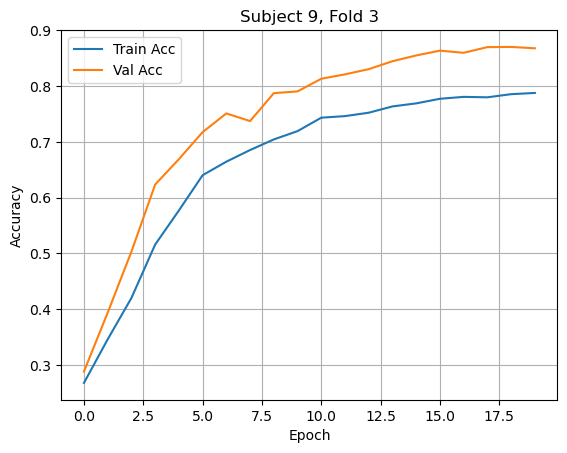

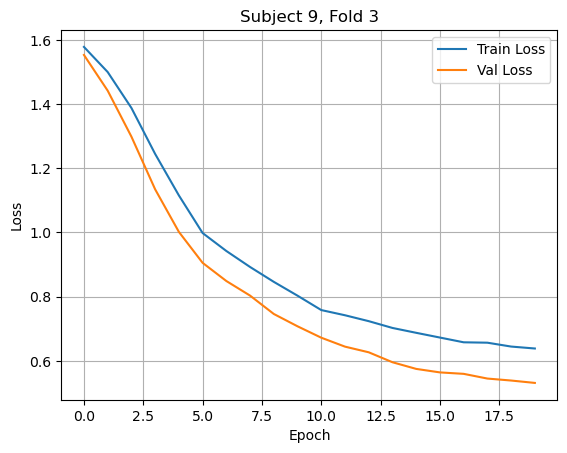

In [85]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'Subject {subject_id}, Fold {fold_id}')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f"acc_subject{subject_id}_fold{fold_id}.png"))
plt.show()

plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Subject {subject_id}, Fold {fold_id}')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f"loss_subject{subject_id}_fold{fold_id}.png"))
plt.show()


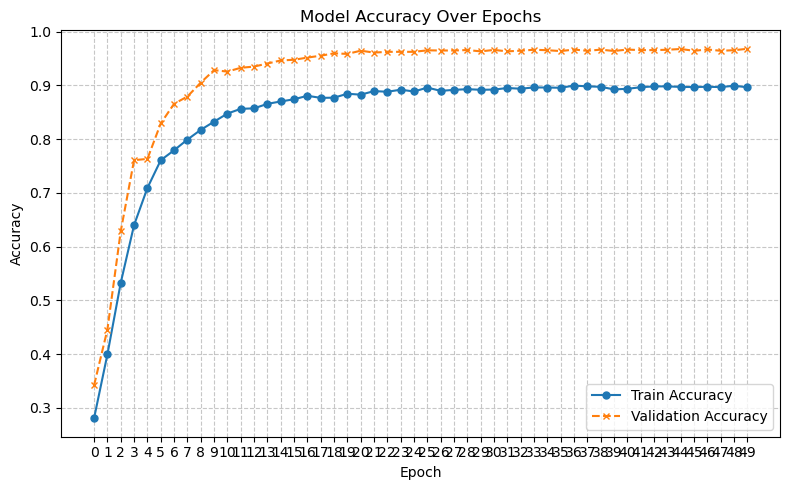

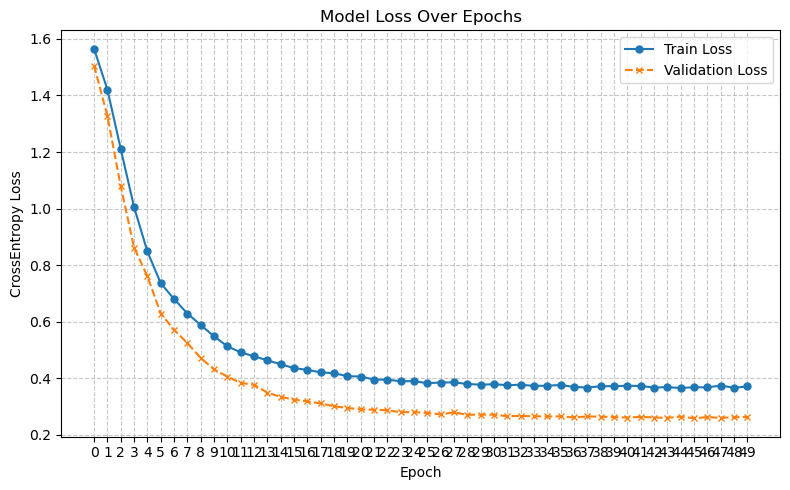

In [43]:
import matplotlib.pyplot as plt

# === Accuracy Plot ===
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label='Train Accuracy', marker='o', linestyle='-', markersize=5)
plt.plot(val_accuracies, label='Validation Accuracy', marker='x', linestyle='--', markersize=5)
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(len(train_accuracies)))  # One tick per epoch
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_curve.png", dpi=300)
plt.show()

# === Loss Plot ===
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', marker='o', linestyle='-', markersize=5)
plt.plot(val_losses, label='Validation Loss', marker='x', linestyle='--', markersize=5)
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
plt.xticks(range(len(train_losses)))  # One tick per epoch
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)
plt.show()


In [86]:
import torch
import os
import re
from collections import defaultdict

def load_all_fine_tuned_models(model_dir, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model_dict = defaultdict(dict)  # model_dict[subject_id][fold_id] = model

    # List all fine-tuned model files
    checkpoint_files = sorted([
        f for f in os.listdir(model_dir)
        if re.match(r"subject\d+_fold\d+_fine_tuned\.pt", f)
    ])

    print(f"Found {len(checkpoint_files)} fine-tuned models.")

    for ckpt in checkpoint_files:
        match = re.match(r"subject(\d+)_fold(\d+)_fine_tuned\.pt", ckpt)
        if not match:
            continue

        subject_id = int(match.group(1))
        fold_id = int(match.group(2))

        # Build full path
        model_path = os.path.join(model_dir, ckpt)

        # Create model instance and load weights
        base_model = CNNPredictiveCodingDE_Attn()
        model = EEGEmotionClassifier(base_model, n_classes=5)

        state_dict = torch.load(model_path, map_location=device)
        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()

        model_dict[subject_id][fold_id] = model
        print(f"Loaded model: Subject {subject_id}, Fold {fold_id}")

    return model_dict


Found 48 model checkpoints.


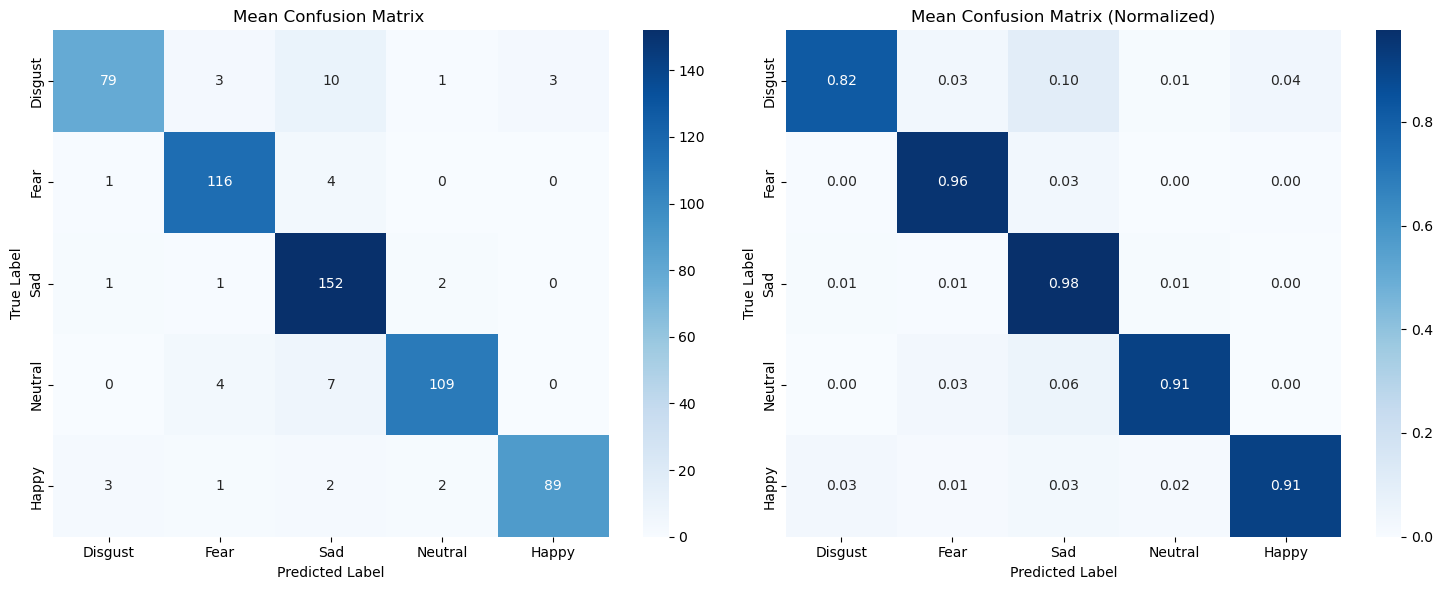

              precision    recall  f1-score   support

     Disgust       0.95      0.82      0.88      4624
        Fear       0.93      0.96      0.94      5824
         Sad       0.87      0.98      0.92      7472
     Neutral       0.96      0.91      0.94      5728
       Happy       0.96      0.91      0.94      4672

    accuracy                           0.92     28320
   macro avg       0.93      0.92      0.92     28320
weighted avg       0.93      0.92      0.92     28320

 Mean Validation Accuracy: 0.9239


In [92]:
import torch
import os
import re
import pickle
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import DataLoader, TensorDataset

# -------- Load Per-Fold Data Function --------
def get_finetune_loader_for_subject_fold(subject_id, fold_idx, batch_size=64):
    with open("/home/rml/Niki/DE/past_by_subject_DE.pkl", "rb") as f:
        X_data = pickle.load(f)
    with open("/home/rml/Niki/DE/past_labels_by_subject_DE.pkl", "rb") as f:
        y_data = pickle.load(f)
    with open("/home/rml/Niki/DE/folds_by_subject_trial_DE.pkl", "rb") as f:
        folds = pickle.load(f)

    fold = folds[subject_id][fold_idx]
    test_indices = fold['test_indices']

    X_val = np.stack([X_data[subject_id][i] for i in test_indices])
    y_val = np.array([y_data[subject_id][i] for i in test_indices])

    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.long)

    if X_val.ndim == 4 and X_val.shape[1] == 1:
        X_val = X_val.squeeze(1)

    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
    return val_loader, y_val

# -------- Load Models and Collect Predictions --------
model_dir = "/home/rml/Niki/fine_tuned"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

conf_matrix_sum = np.zeros((5, 5), dtype=np.float64)
all_preds = []
all_labels = []

checkpoint_files = sorted([
    f for f in os.listdir(model_dir) if re.match(r"subject\d+_fold\d+_fine_tuned\.pt", f)
])

print(f"Found {len(checkpoint_files)} model checkpoints.")

for ckpt in checkpoint_files:
    match = re.match(r"subject(\d+)_fold(\d+)_fine_tuned\.pt", ckpt)
    if not match:
        continue

    subject_id = int(match.group(1))
    fold_id = int(match.group(2)) - 1  # convert 1,2,3 → 0,1,2

    try:
        val_loader, y_val_tensor = get_finetune_loader_for_subject_fold(subject_id, fold_id)
    except (IndexError, KeyError) as e:
        print(f"Skipping Subject {subject_id}, Fold {fold_id + 1} — {str(e)}")
        continue

    base_model = CNNPredictiveCodingDE_Attn()
    model = EEGEmotionClassifier(base_model, n_classes=5)
    model.load_state_dict(torch.load(os.path.join(model_dir, ckpt), map_location=device))
    model.to(device)
    model.eval()

    fold_preds, fold_labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            preds = model(xb).argmax(dim=1).cpu()
            fold_preds.extend(preds.tolist())
            fold_labels.extend(yb.tolist())

    cm = confusion_matrix(fold_labels, fold_preds, labels=[0, 1, 2, 3, 4])
    conf_matrix_sum += cm

    all_preds.extend(fold_preds)
    all_labels.extend(fold_labels)

# -------- Final Confusion Matrices --------
cm_mean = conf_matrix_sum / len(checkpoint_files)
cm_normalized = cm_mean / cm_mean.sum(axis=1, keepdims=True)

target_names = ['Disgust', 'Fear', 'Sad', 'Neutral', 'Happy']

# -------- Side-by-side Confusion Matrices --------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Raw count matrix
sns.heatmap(cm_mean, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title("Mean Confusion Matrix ")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Normalized matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title("Mean Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# -------- Classification Report & Accuracy --------
print(classification_report(all_labels, all_preds, target_names=target_names))
print(f" Mean Validation Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
